# Ode to Joy, scored as a landscape

The inverse of `sound_of_paintings` (color -> sound): here the **score itself is the instruction**, not audio. No recording, no synthesis, no pitch-detection -- just the melody's own note data driving a picture directly, so there's no copyright question at all (the composition is public domain; we never touch a specific performance).

**Scope:** the famous theme entrance from the finale of Beethoven's 9th -- the full 16-bar tune (all four phrases, 62 notes), stated four times with Beethoven's own increasing orchestration. Verified directly against the IMSLP full score (bars 92, ~112, 140, 164, matching Cook's structural analysis) rather than assumed from memory:

| Bar | Instruments entering | Real marking |
|---|---|---|
| 92 | Cello + Bass | **p** |
| ~112 | + Bassoon, + Viola | **p, "sempre piano"** (explicitly told *not* to build) |
| 140 | + Violin | **p dolce** |
| ~149-163 | (no new instrument) | a written crescendo |
| 164 | Full orchestra (remaining winds/brass burst in together) | **f** |

That's a real correction from an earlier draft that assumed an evenly-stepped pp -> p -> mf -> ff ramp -- the actual score stays flat and soft through three straight entrances (explicitly marked *not* to grow louder) and saves the only real dynamic event for one late crescendo into the forte tutti. What builds across the first three stages is **timbre** (more instruments, same softness), not loudness -- so the mapping now follows that:

- **Register -> terrain depth.** Bass is the ground you're standing on (nearest, present the whole time); bassoon joins the midground alongside viola (verified: they enter together); violin is the farthest ridge. Each layer fades in continuously right as its instrument joins the score.
- **Dynamic marking -> the sky.** Flat and dark/cool through Var. I-III (matching "sempre piano"/"p dolce"), warming sharply only into Var. IV -- the sky's one real event lands exactly where the score's one real event does.
- **The bar-164 tutti -> a sudden forest, not a fourth clean band.** The real score has flute, oboe, clarinet, horns, and trumpets -- all silent through bars 92-163 -- burst in together at forte. A fourth smooth terrain layer would understate that; instead a dense scatter of small trees crowns the violin ridge specifically in Var. IV, still melody-driven (same verified pitch contour, not new data) but visually chaotic the way a real full-orchestra entrance actually is.
- **Melody pitch contour -> the mountain silhouette itself,** restated identically in all four sections.

**Scope note:** full-theme fidelity and glance-recognizability are in real tension -- the complete 62-note theme, compressed into a quarter of the panorama's width, is too dense to trace by eye no matter how it's styled (confirmed directly: an isolated plot of just the opening phrase, given real room, read instantly as the tune; the same notes crammed into this width did not). Resolution: the terrain itself stays driven by the complete, honest 62-note theme -- nothing is cut. Only the glowing trace line is masked to the recognizable opening phrase (`E E F G G F E D C C D E E D D`) each time it recurs, so the landscape is fully true to the score and the part a viewer can actually follow by eye is the part that reads as "Ode to Joy."

The note sequence was verified against two independent beginner-piano transcriptions (not just recalled from memory) before encoding, since the whole point of this piece is fidelity to the actual notes.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

NOTE_SEMITONE = {"C": 0, "D": 2, "E": 4, "F": 5, "G": 7, "A": 9, "B": 11}

# the four 4-bar phrases of the full theme, letter notes -- cross-checked against two
# independent published transcriptions. Full theme drives the terrain (complete
# fidelity to the actual score) -- see HOOK_LEN below for the recognizable opening
# phrase that gets highlighted separately, rather than cropping the theme itself.
LINE1 = "E E F G G F E D C C D E E D D".split()
LINE2 = "E E F G G F E D C C D E D C C".split()
LINE3 = "D D E C D E F E C D E F E D C D G".split()
LINE4 = LINE2
MELODY = LINE1 + LINE2 + LINE3 + LINE4

HOOK_LEN = len(LINE1)  # the recognizable opening phrase, as a note-count into MELODY

PITCH = np.array([NOTE_SEMITONE[n] for n in MELODY], dtype=float)
PITCH = (PITCH - PITCH.min()) / (PITCH.max() - PITCH.min())  # normalized 0..1 contour
len(MELODY), PITCH.round(2)

(62,
 array([0.57, 0.57, 0.71, 1.  , 1.  , 0.71, 0.57, 0.29, 0.  , 0.  , 0.29,
        0.57, 0.57, 0.29, 0.29, 0.57, 0.57, 0.71, 1.  , 1.  , 0.71, 0.57,
        0.29, 0.  , 0.  , 0.29, 0.57, 0.29, 0.  , 0.  , 0.29, 0.29, 0.57,
        0.  , 0.29, 0.57, 0.71, 0.57, 0.  , 0.29, 0.57, 0.71, 0.57, 0.29,
        0.  , 0.29, 1.  , 0.57, 0.57, 0.71, 1.  , 1.  , 0.71, 0.57, 0.29,
        0.  , 0.  , 0.29, 0.57, 0.29, 0.  , 0.  ]))

## The four variations and the terrain layers

Each variation is one full statement of the complete 16-bar theme. `dynamic` is Beethoven's own dynamic marking (pp/p/mf/ff) mapped to 0..1, driving the sky. Each terrain layer has a baseline height, an amplitude (how much the melody's pitch contour pushes it up), a color, and the x-position where that instrument first enters the score -- everything before that point smoothly collapses toward zero height instead of hard-cutting, so the whole thing reads as one continuous landscape rather than four stitched tiles.

In [2]:
VARIATIONS = [
    {"label": "Var. I — cello & bass, p"},
    {"label": "Var. II — + bassoon, viola (sempre piano)"},
    {"label": "Var. III — + violin, p dolce"},
    {"label": "Var. IV — full orchestra, f"},
]
N_VAR = len(VARIATIONS)
CENTERS = np.arange(N_VAR) + 0.5

LAYER_STYLE = {
    # tutti sits farthest/highest and is drawn first, so the nearer layers
    # below naturally occlude everything but its tallest peaks -- it's a
    # normal continuous waveform layer like the rest, just tall enough that
    # only its melodic high points rise above the mountain line. fade=0.12
    # (vs. 0.5 for the others) is still a much quicker burst -- but not the
    # near-instant 0.05 that made the glow line spike almost vertical at
    # the entrance.
    "tutti":   dict(baseline=0.60, amp=0.34, color="#ffffff", enters_at=3.0, fade=0.12,
                     glow=("#c9a227", "#7a5a10")),  # gold glow, visible against white fill
    "violin":  dict(baseline=0.62, amp=0.16, color="#8fb8c9", enters_at=2.0),  # farthest, palest
    "viola":   dict(baseline=0.42, amp=0.20, color="#4f7a5c", enters_at=1.0),  # midground
    "bassoon": dict(baseline=0.24, amp=0.14, color="#7a5a2e", enters_at=1.0),  # joins with viola, warm woodwind brown
    "bass":    dict(baseline=0.10, amp=0.22, color="#2a3b28", enters_at=0.0),  # nearest, darkest
}
LAYER_ORDER = ["tutti", "violin", "viola", "bassoon", "bass"]  # draw far to near

SKY_COLD = np.array([0.09, 0.11, 0.22])   # night/dawn blue
SKY_WARM = np.array([1.00, 0.78, 0.35])   # sunrise gold
FADE_WIDTH = 0.5  # default fade width; individual layers may override via style["fade"]

# Simon: "too bi-modal, needs more gradient in the middle third. Scooch the
# yellow all the way to the right third, darker in the left third." Thirds
# of the total width, not tied to variation boundaries: flat dark for the
# left third, one continuous gradient across the middle third, flat warm
# gold for the right third. (The bar-164 tutti still falls at x=3.0, inside
# the already-bright right third, so the one real score fact -- forte fully
# arrived by the tutti -- still holds; everything about the curve's shape
# is stylization on top of that.)
THIRD = N_VAR / 3
DYN_X = np.array([0.0, THIRD, 2 * THIRD, N_VAR])
DYN_Y = np.array([0.10, 0.10, 0.80, 0.80])


def dynamic_at(x):
    return np.interp(x, DYN_X, DYN_Y)


def smoothstep(x, edge0, edge1):
    t = np.clip((x - edge0) / (edge1 - edge0), 0, 1)
    return t * t * (3 - 2 * t)

## Render: sky, sun trail, terrain

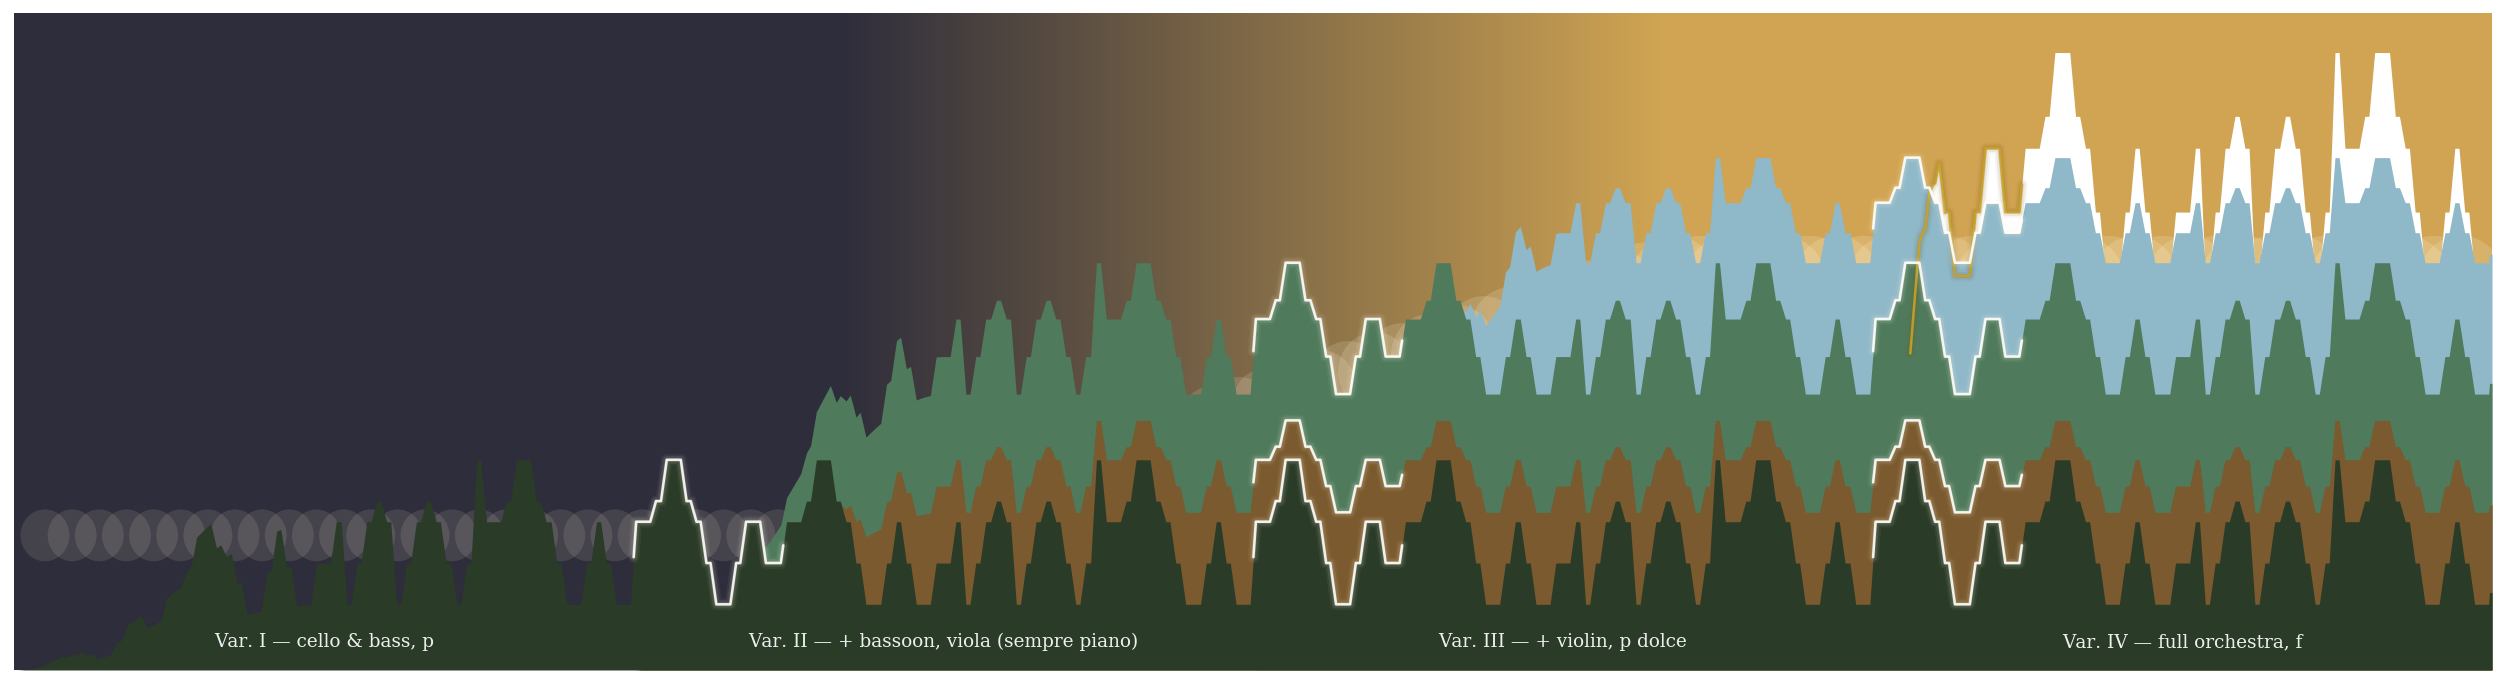

saved musical_landscape.png


In [6]:
def draw_sky(ax):
    xs = np.linspace(0, N_VAR, 600)
    dyn = dynamic_at(xs)
    rgb = SKY_COLD[None, :] + (SKY_WARM - SKY_COLD)[None, :] * dyn[:, None]
    img = np.tile(rgb[None, :, :], (2, 1, 1))
    ax.imshow(img, extent=(0, N_VAR, 0, 1), origin="lower", aspect="auto", zorder=0)


def draw_sun_trail(ax, n_samples=90):
    xs = np.linspace(0.05, N_VAR - 0.05, n_samples)
    dyn = dynamic_at(xs)
    sun_y = 0.15 + 0.55 * dyn
    for x, y, d in zip(xs, sun_y, dyn):
        ax.add_patch(Circle((x, y), 0.035 + 0.045 * d, color="#fff6d8",
                             alpha=0.10 + 0.10 * d, zorder=1, linewidth=0))


def draw_terrain(ax, n_points=3000):
    """Terrain fill *and* a glowing ridge line tracing the melody along each
    layer's own skyline -- bass's line first, then bassoon+viola join
    together along the midground ridge, then violin along the farthest
    peak, then the tutti layer's own ridge bursts in above all of them. One
    mechanism for all five layers: fill from the ground to
    `presence * (baseline + amp*contour)`, glow the ridge where the layer
    has entered and we're in the recognizable opening phrase. tutti is
    drawn *farthest back* (lowest zorder) with a tall enough baseline+amp
    that only its melodic high points rise above the nearer layers -- same
    construction as every other layer, not a bespoke scatter (an earlier
    draft used random independent trees for tutti; Simon called it out as
    inconsistent with the rest of the piece: "it's supposed to be a
    waveform, just like all the others").

    The terrain height is driven by the FULL theme (all 62 notes, complete
    fidelity to the score) -- but at this width the full theme reads as
    generic texture, not a traceable shape (confirmed by direct comparison:
    an isolated plot of just the opening phrase, given real room, read
    instantly; the full theme crammed into a quarter of this panorama did
    not). Rather than crop the theme to fix that, the glow is masked to only
    trace the recognizable opening phrase (HOOK_LEN notes) each time it
    recurs -- the landscape stays fully honest, the highlight stays legible."""
    xs = np.linspace(0, N_VAR, n_points)
    melody_x = xs % 1.0  # full theme restated once per variation
    note_idx = np.clip((melody_x * len(PITCH)).astype(int), 0, len(PITCH) - 1)
    contour = PITCH[note_idx]
    points_per_note = n_points / (N_VAR * len(PITCH))
    smooth_k = max(3, int(points_per_note / 2) | 1)  # odd, ~1/2 of a note's width
    kernel = np.ones(smooth_k) / smooth_k
    contour = np.convolve(contour, kernel, mode="same")
    hook_mask = note_idx < HOOK_LEN
    for i, name in enumerate(LAYER_ORDER):
        style = LAYER_STYLE[name]
        fade = style.get("fade", FADE_WIDTH)
        presence = smoothstep(xs, style["enters_at"], style["enters_at"] + fade)
        ys = presence * (style["baseline"] + style["amp"] * contour)
        ax.fill_between(xs, 0, ys, color=style["color"], zorder=10 + i, linewidth=0)

        # ridge glow only where the layer is essentially fully entered (not
        # just barely begun -- a low threshold let the steepest part of a
        # short fade read as a near-vertical spike rather than a ridge) AND
        # we're in the recognizable opening phrase
        glow_inner, glow_outer = style.get("glow", ("#ffffff", "#fff6d8"))
        ys_glow = np.where((presence > 0.5) & hook_mask, ys, np.nan)
        for lw, alpha in [(6, 0.05), (4, 0.09), (2, 0.16)]:
            ax.plot(xs, ys_glow, color=glow_outer, linewidth=lw, alpha=alpha,
                     zorder=30 + i, solid_capstyle="round")
        ax.plot(xs, ys_glow, color=glow_inner, linewidth=1.3, alpha=0.9,
                 zorder=31 + i, solid_capstyle="round")
    return contour


def render(out_path="musical_landscape.png"):
    fig, ax = plt.subplots(figsize=(18, 5.2), dpi=140)
    draw_sky(ax)
    draw_sun_trail(ax)
    draw_terrain(ax, n_points=3000)
    for v, cx in zip(VARIATIONS, CENTERS):
        ax.text(cx, 0.03, v["label"], ha="center", va="bottom", fontsize=9.5,
                color="white", zorder=50, fontfamily="serif", alpha=0.92)
    ax.set_xlim(0, N_VAR)
    ax.set_ylim(0, 1)
    ax.axis("off")
    
    fig.tight_layout(rect=(0, 0, 1, 0.96))
    fig.savefig(out_path, facecolor="white")
    plt.show()
    print(f"saved {out_path}")

render()

## Takeaways

- No audio anywhere in this pipeline -- score data (pitch, dynamic marking, instrument entrance) drives the picture directly. That sidesteps every pitch-detection/copyright issue that a real-audio approach would carry.
- The "landscape" framing wasn't forced: Beethoven's own four-variation orchestration already has a near/far depth structure (which instrument enters when) and a quiet/loud energy arc that map onto landscape depth and time-of-day almost without translation.
- Continuous fade-ins (via `smoothstep` collapsing each layer toward zero height before its entrance) were the fix for the first draft, which rendered as four visibly stitched panels instead of one landscape -- matches the same lesson as `feedback_sonification_design`: discrete per-segment parameters read as seams unless smoothed into a continuous curve.